# Nearshore downscaling: the Dutch coast at Noordwijk

This notebook takes **SWAN 1 km hindcast spectra** for Dutch waters and pushes them through
the last-stage nearshore transformation to a point off **Noordwijk aan Zee**, over GEBCO 2023
bathymetry — the same bathymetry the parent SWAN model used.

The period covers storms **Pia** (late Dec 2023) and **Henk** (early Jan 2024).

What it illustrates, in order:

1. the local bathymetry and where the boundary spectra come from
2. **ray geometry** — which offshore directions can physically reach the target
3. the transformation itself, and how fast it runs
4. offshore vs nearshore wave height through the storms
5. the **directional spectrum** before and after transformation
6. **validation** against SWAN's own answer at a nearshore site
7. what **depth-limited breaking** contributes

Requirements: `uv sync --extra datamesh --extra notebooks` and `DATAMESH_TOKEN` in the environment.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Validated palette (dataviz reference instance, light mode)
SURFACE = "#fcfcfb"
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
BLUE, AQUA, YELLOW, ORANGE = "#2a78d6", "#1baf7a", "#eda100", "#eb6834"
LAND = "#e4e3dd"

# Sequential blue ramp, steps 100 -> 700 (one hue, light -> dark)
BLUE_STEPS = [
    "#cde2fb",
    "#b7d3f6",
    "#9ec5f4",
    "#86b6ef",
    "#6da7ec",
    "#5598e7",
    "#3987e5",
    "#2a78d6",
    "#256abf",
    "#1c5cab",
    "#184f95",
    "#104281",
    "#0d366b",
]
BLUES = LinearSegmentedColormap.from_list("blues", BLUE_STEPS)  # depth: shallow light -> deep dark
ENERGY = LinearSegmentedColormap.from_list("energy", ["#fcfcfb"] + BLUE_STEPS)

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.size": 10,
        "axes.edgecolor": "#d5d4cf",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "600",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "grid.color": "#ecebe6",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
    }
)


def label_end(ax, x, y, text, color, dx=6, dy=0):
    """Direct label at a series' right end (relief rule for low-contrast hues).

    Pass dy (points) to separate labels where two series converge.
    """
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        color=color,
        fontsize=9,
        fontweight="600",
        va="center",
        clip_on=False,
    )


def hs_of(efth, freqs, dirs):
    """Hm0 from a directional spectrum array (..., nf, ndir)."""
    from waveray.breaking import hm0

    return hm0(efth, freqs, dirs)


def metrics(pred, obs):
    import numpy as np

    ok = np.isfinite(pred) & np.isfinite(obs)
    p, o = pred[ok], obs[ok]
    return {
        "n": int(ok.sum()),
        "r": float(np.corrcoef(p, o)[0, 1]),
        "bias": float(np.mean(p - o)),
        "rmse": float(np.sqrt(np.mean((p - o) ** 2))),
        "si": float(np.sqrt(np.mean((p - o) ** 2)) / np.mean(o)),
    }

In [2]:
import os
import time

import numpy as np
from oceanum.datamesh import Connector

from waveray import SiteModel, fetch_datamesh_bathymetry, ray_paths_geojson

assert os.environ.get("DATAMESH_TOKEN"), "DATAMESH_TOKEN is not set"

BBOX = (3.85, 52.00, 4.55, 52.50)  # southern Holland coast
TARGET = (4.42, 52.24)  # ~1.5 km off Noordwijk aan Zee
BATHY = "gebco_2023"  # matches the parent SWAN model
SPEC = "oceanum_wave_dutch_era5_v1_spec"  # SWAN 1 km, hourly, ERA5-forced
TIMES = ["2023-12-15T00:00:00Z", "2024-01-15T00:00:00Z"]  # storms Pia + Henk
N_BOUNDARY = 6
BOUNDARY_MIN_DEPTH = 16.0  # [m] draw boundary sites from this arc

conn = Connector()

## 1. Local bathymetry

`fetch_datamesh_bathymetry` pulls the GEBCO subset and projects it onto a local tangent
plane (metres). Depth is positive down; land is anything at or above the waterline.

In [3]:
grid = fetch_datamesh_bathymetry(BATHY, bbox=BBOX, positive="up")
print(f"grid: {grid.x.size} x {grid.y.size} nodes, spacing ~{grid.spacing[0]:.0f} m")
print(f"depth range: {np.nanmin(grid.depth[~grid.land]):.1f} - {np.nanmax(grid.depth):.1f} m")

grid: 168 x 120 nodes, spacing ~284 m
depth range: 1.0 - 41.0 m


## 2. Boundary spectra and the target

The hindcast supplies spectra at discrete sites. We take an **arc of six offshore sites**
(deep enough to be outside the last-stage transformation) as the boundary condition, and
keep one shallow interior site aside as an independent **truth** for validation later.

The target is nudged seaward until it lands on a wet GEBCO cell — at ~450 m resolution the
grid does not resolve the beach step.

In [4]:
probe = conn.query(
    {
        "datasource": SPEC,
        "geofilter": {"type": "bbox", "geom": list(BBOX)},
        "timefilter": {"times": [TIMES[0], TIMES[0]]},
    }
)
lons = np.atleast_1d(probe["lon"].values)
lats = np.atleast_1d(probe["lat"].values)
xs, ys = grid.to_local(lons, lats)
depths = grid.sample_depth(xs, ys)

# nudge the target onto a wet cell
tlon, tlat = TARGET
for _ in range(40):
    tx_, ty_ = grid.to_local(np.array([tlon]), np.array([tlat]))
    if grid.sample_depth(tx_, ty_)[0] >= 3.0:
        break
    tlon -= 0.002
tx, ty = float(tx_[0]), float(ty_[0])

# boundary: offshore arc, spread by azimuth around the target
deep = np.flatnonzero(depths >= BOUNDARY_MIN_DEPTH)
az = np.arctan2(ys[deep] - ty, xs[deep] - tx)
order = deep[np.argsort(az)]
picks = order[np.linspace(0, order.size - 1, N_BOUNDARY).astype(int)]
bpts = [(float(lons[i]), float(lats[i])) for i in picks]

# truth: shallowest interior site, safely inside the grid
xmin, xmax, ymin, ymax = grid.bounds
margin = 2000.0
inside = (xs > xmin + margin) & (xs < xmax - margin) & (ys > ymin + margin) & (ys < ymax - margin)
interior = [
    i for i in range(lons.size) if i not in set(picks) and inside[i] and 4.0 < depths[i] < 12.0
]
truth = min(interior, key=lambda i: depths[i])

print(f"{lons.size} hindcast sites in domain")
d_target_m = grid.sample_depth(np.array([tx]), np.array([ty]))[0]
print(f"target      ({tlon:.3f}E, {tlat:.3f}N)  depth {d_target_m:.1f} m")
print(f"truth site  ({lons[truth]:.3f}E, {lats[truth]:.3f}N)  depth {depths[truth]:.1f} m")
print(f"boundary    {[(round(a, 2), round(b, 2)) for a, b in bpts]}")

119 hindcast sites in domain
target      (4.416E, 52.240N)  depth 3.4 m
truth site  (4.300E, 52.150N)  depth 9.8 m
boundary    [(3.85, 52.2), (4.15, 52.15), (4.4, 52.35), (4.1, 52.45), (4.2, 52.3), (3.85, 52.25)]


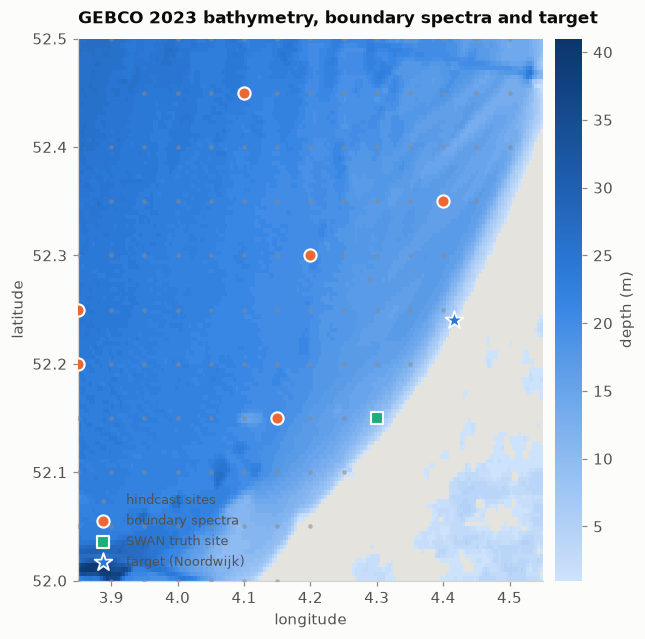

In [5]:
glon, glat = grid.to_lonlat(grid.x, grid.y)
depth_masked = np.where(grid.land, np.nan, grid.depth)

fig, ax = plt.subplots(figsize=(7.4, 6.4))
ax.set_facecolor(LAND)
pc = ax.pcolormesh(glon, glat, depth_masked, cmap=BLUES, shading="auto", rasterized=True)
cb = fig.colorbar(pc, ax=ax, pad=0.02, fraction=0.045)
cb.set_label("depth (m)", color=INK_2)
cb.outline.set_visible(False)

ax.scatter(lons, lats, s=9, c=INK_MUTED, alpha=0.55, linewidths=0, label="hindcast sites", zorder=3)
blon, blat = [p[0] for p in bpts], [p[1] for p in bpts]
ax.scatter(
    blon,
    blat,
    s=64,
    facecolor=ORANGE,
    edgecolor=SURFACE,
    linewidth=1.4,
    label="boundary spectra",
    zorder=5,
)
ax.scatter(
    [lons[truth]],
    [lats[truth]],
    s=70,
    marker="s",
    facecolor=AQUA,
    edgecolor=SURFACE,
    linewidth=1.4,
    label="SWAN truth site",
    zorder=5,
)
ax.scatter(
    [tlon],
    [tlat],
    s=150,
    marker="*",
    facecolor=BLUE,
    edgecolor=SURFACE,
    linewidth=1.2,
    label="target (Noordwijk)",
    zorder=6,
)

ax.set(
    xlabel="longitude",
    ylabel="latitude",
    title="GEBCO 2023 bathymetry, boundary spectra and target",
)
ax.set_aspect(1 / np.cos(np.deg2rad(52.25)))
ax.legend(loc="lower left", fontsize=8.5, labelcolor=INK_2)
plt.show()

## 3. Ray geometry — which directions can reach the target?

The operator is built by tracing rays **backward** from the target across every
(frequency, direction) bin. A ray either escapes to the domain edge — where it picks up
boundary energy — or runs aground, contributing nothing.

The picture below is the physical heart of the method: from a 3.4 m target, only a narrow
cone around shore-normal connects to the open sea. That is Snell's law drawn out — refraction
turns everything else into the beach.

In [6]:
gj = ray_paths_geojson(
    grid,
    (tx, ty),
    freqs=np.array([0.06, 0.09, 0.14]),  # 16.7 s, 11.1 s, 7.1 s
    dirs=np.arange(0.0, 360.0, 15.0),
)
n_exit = sum(s == "exited" for f in gj["features"] for s in f["properties"]["status"])
print(
    f"{len(gj['features'])} (freq, dir) bins; {n_exit} rays reach the boundary, the rest ground out"
)

72 (freq, dir) bins; 10 rays reach the boundary, the rest ground out


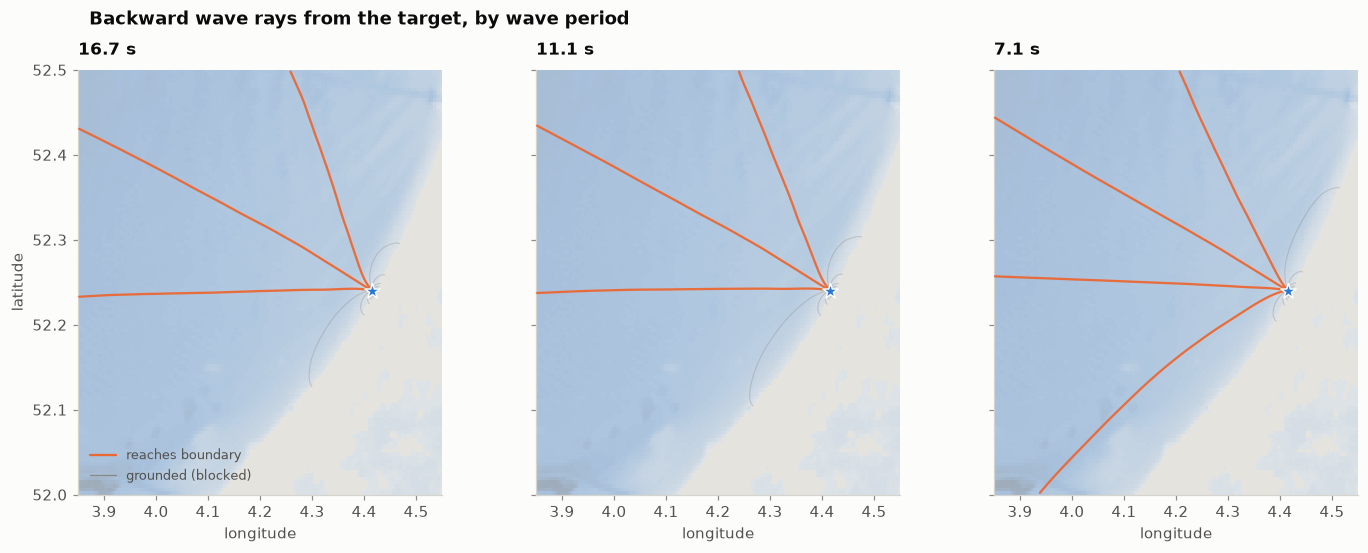

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.9), sharey=True)
periods = sorted({f["properties"]["period"] for f in gj["features"]}, reverse=True)

for ax, period in zip(axes, periods, strict=True):
    ax.set_facecolor(LAND)
    ax.pcolormesh(glon, glat, depth_masked, cmap=BLUES, shading="auto", alpha=0.32, rasterized=True)
    for feat in gj["features"]:
        if feat["properties"]["period"] != period:
            continue
        exited = feat["properties"]["status"][0] == "exited"
        for line in feat["geometry"]["coordinates"]:
            arr = np.asarray(line)
            ax.plot(
                arr[:, 0],
                arr[:, 1],
                color=ORANGE if exited else INK_MUTED,
                lw=1.5 if exited else 0.7,
                alpha=0.95 if exited else 0.35,
                zorder=4 if exited else 3,
            )
    ax.scatter(
        [tlon],
        [tlat],
        s=110,
        marker="*",
        facecolor=BLUE,
        edgecolor=SURFACE,
        linewidth=1.0,
        zorder=6,
    )
    ax.set(xlabel="longitude", title=f"{period:.1f} s")
    ax.set_aspect(1 / np.cos(np.deg2rad(52.25)))

axes[0].set_ylabel("latitude")
axes[0].plot([], [], color=ORANGE, lw=1.5, label="reaches boundary")
axes[0].plot([], [], color=INK_MUTED, lw=0.9, label="grounded (blocked)")
axes[0].legend(loc="lower left", fontsize=8.5, labelcolor=INK_2)
fig.suptitle(
    "Backward wave rays from the target, by wave period",
    x=0.09,
    y=0.99,
    ha="left",
    fontsize=11.5,
    fontweight="600",
    color=INK,
)
plt.tight_layout()
plt.show()

Longer waves feel the bottom sooner, so their rays bend harder: the arrival cone narrows as
period grows. Every grounded ray is a direction from which **no energy can arrive** — that
sheltering is baked into the operator for free.

## 4. Build the operator, transform the hindcast

Building traces the rays once (~10 s). After that, transforming a month of hourly spectra is
a single `einsum`.

In [8]:
def fetch_sites(site_lonlats):
    import xarray as xr

    parts = []
    for lon, lat in site_lonlats:
        ds = conn.query(
            {
                "datasource": SPEC,
                "geofilter": {
                    "type": "bbox",
                    "geom": [lon - 0.004, lat - 0.004, lon + 0.004, lat + 0.004],
                },
                "timefilter": {"times": TIMES},
            }
        )
        sd = next(d for d in ds["efth"].dims if d not in ("time", "freq", "dir"))
        parts.append(ds["efth"].isel({sd: 0}).rename({sd: "site"}))
    return xr.concat(parts, dim="site").transpose("time", "site", "freq", "dir")


efth_b = fetch_sites(bpts)
efth_truth = fetch_sites([(float(lons[truth]), float(lats[truth]))]).isel(site=0)
freqs, dirs = efth_b["freq"].values, efth_b["dir"].values
times = efth_b["time"].values
print(f"{efth_b.sizes['time']} hourly timesteps, {freqs.size} freqs x {dirs.size} directions")

/tmp/ipykernel_1191005/1140353161.py:12: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(parts, dim="site").transpose("time", "site", "freq", "dir")


745 hourly timesteps, 32 freqs x 36 directions


In [9]:
t0 = time.perf_counter()
model = SiteModel.build(
    bathy=grid, target=(tlon, tlat), boundary_points=bpts, freqs=freqs, dirs=dirs
)
t_build = time.perf_counter() - t0

t0 = time.perf_counter()
efth_near = model.transform(efth_b)
t_apply = time.perf_counter() - t0

nt = efth_b.sizes["time"]
print(
    f"operator built in {t_build:.1f} s   (target depth {model.operator.depth_target:.1f} m, "
    f"lost rays {100 * model.operator.attrs['lost_fraction']:.1f}%)"
)
print(f"{nt} spectra transformed in {1e3 * t_apply:.0f} ms  ({nt / t_apply:,.0f} spectra/s)")

operator built in 13.8 s   (target depth 3.4 m, lost rays 0.0%)
745 spectra transformed in 105 ms  (7,123 spectra/s)


## 5. Wave height through the storms

Offshore is the first boundary site; the target sits in 3.4 m of water. Note what happens at
the Henk peak — offshore energy keeps climbing while the target **saturates**: that is the
depth-limited breaking cap, not a modelling artefact.

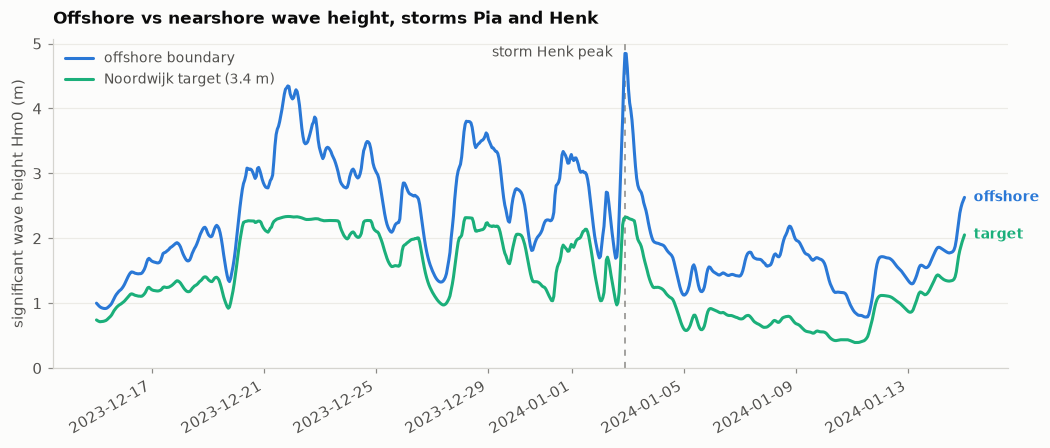

peak offshore 4.85 m  ->  target 2.32 m (48%)


In [10]:
hs_off = hs_of(efth_b.isel(site=0).values, freqs, dirs)
hs_near = hs_of(efth_near.values, freqs, dirs)
ipk = int(np.nanargmax(hs_off))

fig, ax = plt.subplots(figsize=(11.2, 4.4))
ax.grid(axis="y", zorder=0)
ax.plot(times, hs_off, color=BLUE, zorder=3)
ax.plot(times, hs_near, color=AQUA, zorder=4)
label_end(ax, times[-1], hs_off[-1], "offshore", BLUE)
label_end(ax, times[-1], hs_near[-1], "target", AQUA)

ax.axvline(times[ipk], color=INK_MUTED, lw=1, ls=(0, (4, 4)), zorder=2)
ax.annotate(
    "storm Henk peak",
    xy=(times[ipk], hs_off[ipk]),
    xytext=(-8, -2),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    color=INK_2,
)
ax.plot([], [], color=BLUE, label="offshore boundary")
ax.plot([], [], color=AQUA, label="Noordwijk target (3.4 m)")
ax.legend(loc="upper left", fontsize=9, labelcolor=INK_2)
ax.set(
    ylabel="significant wave height Hm0 (m)",
    ylim=(0, None),
    title="Offshore vs nearshore wave height, storms Pia and Henk",
)
fig.autofmt_xdate()
plt.show()

print(
    f"peak offshore {hs_off[ipk]:.2f} m  ->  target {hs_near[ipk]:.2f} m "
    f"({100 * hs_near[ipk] / hs_off[ipk]:.0f}%)"
)

## 6. The directional spectrum, before and after

The transformation is spectral, not parametric — every (frequency, direction) bin is mapped
individually. Refraction rotates energy toward shore-normal and the arrival cone truncates
the directional spread; shoaling and friction reshape the frequency distribution.

Radius is frequency (plot truncated at 0.25 Hz / 4 s); the angle is the direction the waves
come *from*, compass convention.

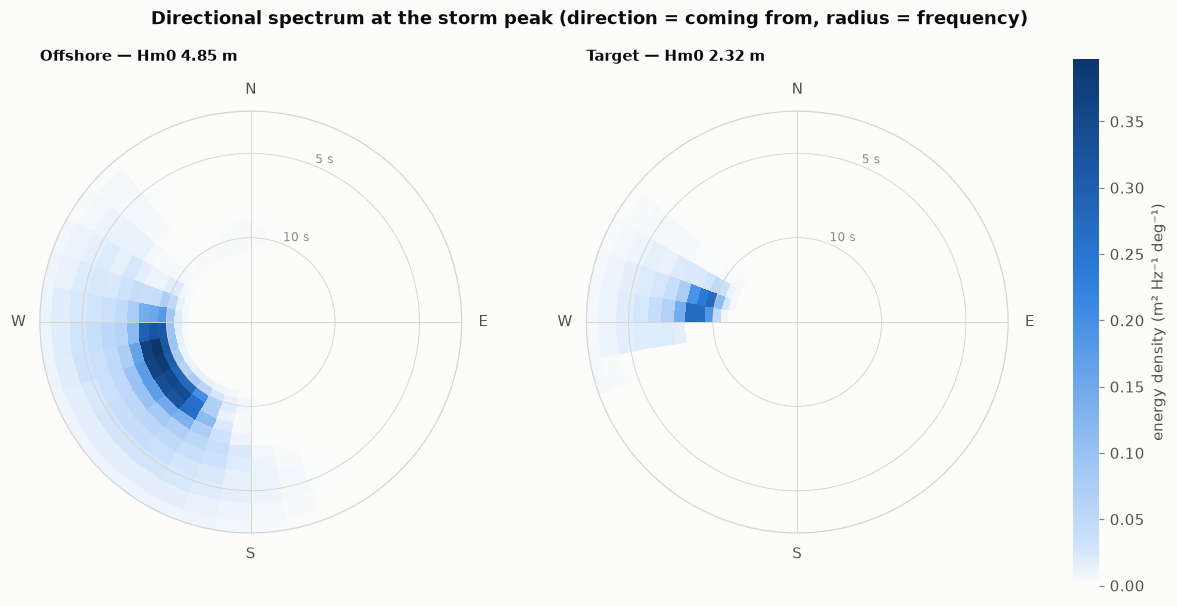

In [11]:
def polar_spectrum(ax, efth, freqs, dirs, title, vmax):
    # The hindcast's dir coordinate is not monotonic (265 -> 5, then 355 -> 275),
    # so sort before pcolormesh, which requires a monotonic theta axis.
    o = np.argsort(dirs % 360.0)
    d_sorted = (dirs % 360.0)[o]
    e = efth[:, o]
    th = np.deg2rad(np.r_[d_sorted, d_sorted[0] + 360.0])  # close the circle
    e = np.c_[e, e[:, :1]]

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)  # nautical: coming-from, clockwise
    m = ax.pcolormesh(th, freqs, e, cmap=ENERGY, shading="auto", vmin=0, vmax=vmax)
    ax.set_ylim(0, 0.25)  # truncated at 0.25 Hz (4 s)
    ax.set_yticks([0.1, 0.2])
    ax.set_yticklabels(["10 s", "5 s"], color=INK_MUTED, fontsize=8)
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(["N", "E", "S", "W"], color=INK_2)
    ax.grid(color="#d5d4cf", lw=0.6)
    ax.set_title(title, pad=14, fontsize=10)
    return m


e_off = efth_b.isel(site=0, time=ipk).values
e_near = efth_near.isel(time=ipk).values
vmax = float(max(e_off.max(), e_near.max()))

fig, axes = plt.subplots(
    1, 2, figsize=(10.6, 5.4), subplot_kw={"projection": "polar"}, layout="constrained"
)
polar_spectrum(axes[0], e_off, freqs, dirs, f"Offshore — Hm0 {hs_off[ipk]:.2f} m", vmax)
m = polar_spectrum(axes[1], e_near, freqs, dirs, f"Target — Hm0 {hs_near[ipk]:.2f} m", vmax)
fig.get_layout_engine().set(wspace=0.12)  # keep the E / W tick labels apart
cb = fig.colorbar(m, ax=axes, pad=0.04, fraction=0.04)
cb.set_label("energy density (m² Hz⁻¹ deg⁻¹)", color=INK_2)
cb.outline.set_visible(False)
fig.suptitle(
    "Directional spectrum at the storm peak (direction = coming from, radius = frequency)",
    fontsize=11.5,
    fontweight="600",
    color=INK,
)
plt.show()

## 6b. The output is a wavespectra spectrum

`transform()` returns an `efth` DataArray carrying wavespectra's CF attributes, so the
`.spec` accessor works on it directly — no conversion step. waveray's own `hm0` uses the
same quadrature as wavespectra, so the two agree exactly.

In [12]:
import wavespectra  # noqa: F401 -- registers the .spec accessor

hs_spec = efth_near.spec.hs(tail=False)
print(f"  .spec.hs()  = {float(hs_spec[ipk]):.3f} m   (waveray hm0 = {hs_near[ipk]:.3f} m)")
print(f"  .spec.tp()  = {float(efth_near.spec.tp()[ipk]):.2f} s")
print(f"  .spec.dpm() = {float(efth_near.spec.dpm()[ipk]):.1f} deg")
print(f"  agreement   = {abs(float(hs_spec[ipk]) - hs_near[ipk]):.2e} m")

  .spec.hs()  = 2.320 m   (waveray hm0 = 2.320 m)


  .spec.tp()  = 8.69 s
  .spec.dpm() = 280.7 deg
  agreement   = 0.00e+00 m


## 7. Validation — against SWAN's own nearshore answer

The honest test: transform the **same** boundary spectra to the interior site SWAN also
solved for, and compare. The ray method never sees SWAN's answer there.

In [13]:
model_v = SiteModel.build(
    bathy=grid,
    target=(float(lons[truth]), float(lats[truth])),
    boundary_points=bpts,
    freqs=freqs,
    dirs=dirs,
)
hs_ray = hs_of(model_v.transform(efth_b).values, freqs, dirs)
hs_swan = hs_of(efth_truth.values, freqs, dirs)
m = metrics(hs_ray, hs_swan)
print(
    f"n={m['n']}   r={m['r']:.3f}   bias={m['bias']:+.2f} m   "
    f"rmse={m['rmse']:.2f} m   SI={m['si']:.2f}"
)

n=745   r=0.992   bias=-0.06 m   rmse=0.10 m   SI=0.06


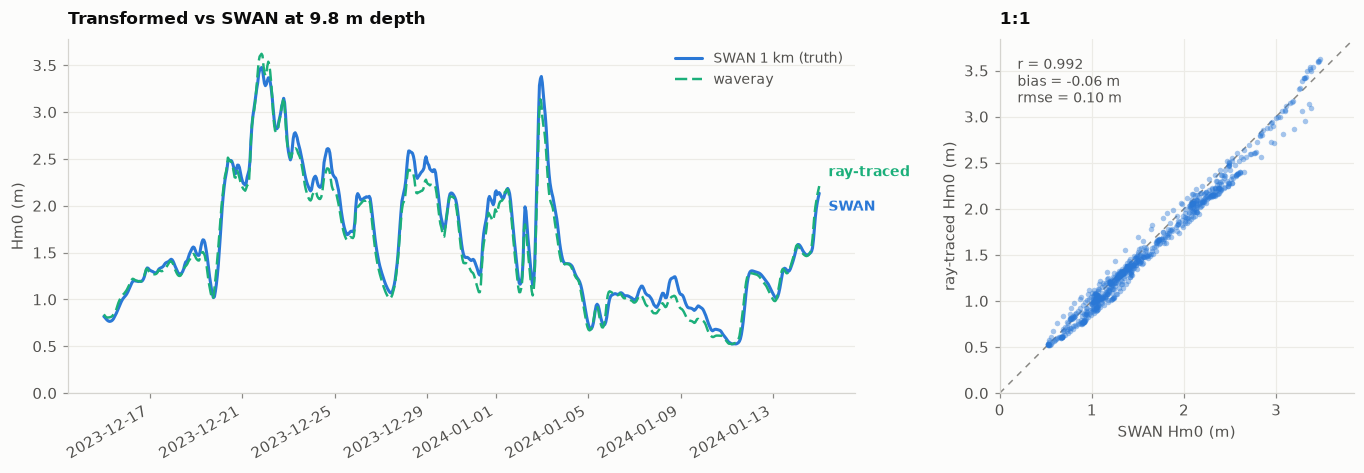

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.4), gridspec_kw={"width_ratios": [2.1, 1]})
ax1.grid(axis="y", zorder=0)
ax1.plot(times, hs_swan, color=BLUE, zorder=3)
ax1.plot(times, hs_ray, color=AQUA, lw=1.6, ls=(0, (5, 2)), zorder=4)
# the two series converge (that is the point), so separate the labels vertically
label_end(ax1, times[-1], hs_swan[-1], "SWAN", BLUE, dy=-9)
label_end(ax1, times[-1], hs_ray[-1], "ray-traced", AQUA, dy=9)
ax1.plot([], [], color=BLUE, label="SWAN 1 km (truth)")
ax1.plot([], [], color=AQUA, ls=(0, (5, 2)), lw=1.6, label="waveray")
ax1.legend(loc="upper right", fontsize=9, labelcolor=INK_2)
ax1.set(
    ylabel="Hm0 (m)", ylim=(0, None), title=f"Transformed vs SWAN at {depths[truth]:.1f} m depth"
)
for lab in ax1.get_xticklabels():
    lab.set_rotation(30)
    lab.set_ha("right")

lim = float(max(hs_swan.max(), hs_ray.max())) * 1.06
ax2.grid(zorder=0)
ax2.plot([0, lim], [0, lim], color=INK_MUTED, lw=1, ls=(0, (4, 4)), zorder=2)
ax2.scatter(hs_swan, hs_ray, s=13, facecolor=BLUE, alpha=0.42, linewidths=0, zorder=3)
ax2.set(
    xlim=(0, lim), ylim=(0, lim), xlabel="SWAN Hm0 (m)", ylabel="ray-traced Hm0 (m)", title="1:1"
)
ax2.set_aspect("equal")
ax2.annotate(
    f"r = {m['r']:.3f}\nbias = {m['bias']:+.2f} m\nrmse = {m['rmse']:.2f} m",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    fontsize=9,
    color=INK_2,
)
plt.tight_layout()
plt.show()

The sandy, gently-sloping Dutch shoreface is close to the ideal case for ray theory: smooth
depth contours, no reefs, no diffracting structures. Reef-fronted coasts (see the Abrolhos
notebook) are harder.

## 8. What breaking contributes

Breaking cannot live inside a linear operator — dissipation depends on the total transformed
energy. It is applied as a **proportional cap** at the target: if transformed Hm0 exceeds the
depth-limited maximum, the whole spectrum is scaled down. Below, the cap only engages in the
storms.

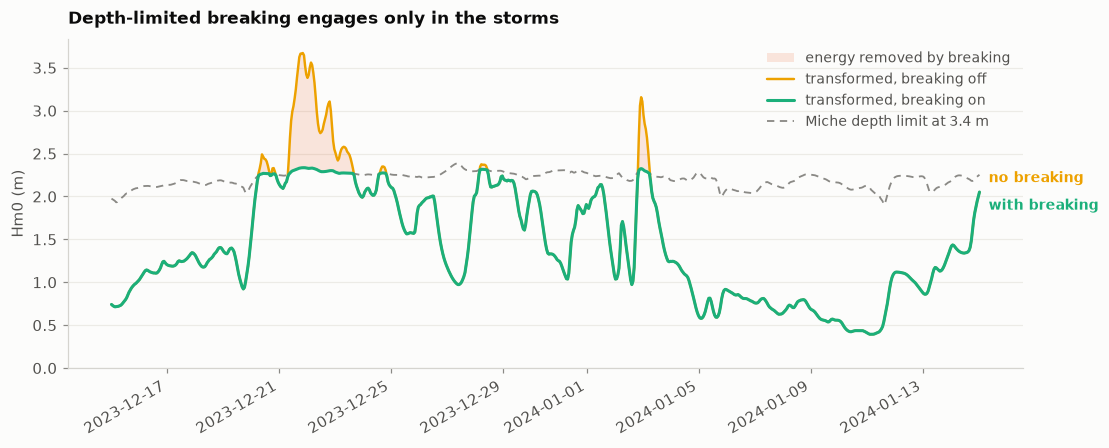

breaking active in 12% of timesteps; peak reduction 1.34 m


In [15]:
from waveray.breaking import hm0_max

efth_unbroken = model.transform(efth_b, breaking=False)
hs_unbroken = hs_of(efth_unbroken.values, freqs, dirs)
d_target = model.operator.depth_target

# The Miche limit at this depth, evaluated at each step's mean frequency -- computed
# from the *unbroken* spectrum, exactly as apply_breaking does internally.
ef = efth_unbroken.values.sum(axis=-1) * (360 / dirs.size)  # (time, nf)
m0 = np.trapezoid(ef, freqs, axis=-1)
m1 = np.trapezoid(ef * freqs, freqs, axis=-1)
fm = np.where(m0 > 0, m1 / np.maximum(m0, 1e-30), np.nan)
cap = hm0_max(np.full(nt, d_target), fm=fm, gamma=model.gamma, method=model.breaking_method)

engaged = hs_unbroken > cap
fig, ax = plt.subplots(figsize=(11.2, 4.4))
ax.grid(axis="y", zorder=0)
ax.fill_between(
    times,
    cap,
    hs_unbroken,
    where=engaged,
    color=ORANGE,
    alpha=0.16,
    linewidth=0,
    zorder=2,
    label="energy removed by breaking",
)
ax.plot(times, hs_unbroken, color=YELLOW, lw=1.6, zorder=3)
ax.plot(times, hs_near, color=AQUA, zorder=5)
ax.plot(times, cap, color=INK_MUTED, lw=1.2, ls=(0, (4, 3)), zorder=4)
label_end(ax, times[-1], hs_unbroken[-1], "no breaking", YELLOW, dy=9)
label_end(ax, times[-1], hs_near[-1], "with breaking", AQUA, dy=-9)

ax.plot([], [], color=YELLOW, lw=1.6, label="transformed, breaking off")
ax.plot([], [], color=AQUA, label="transformed, breaking on")
ax.plot(
    [], [], color=INK_MUTED, lw=1.2, ls=(0, (4, 3)), label=f"Miche depth limit at {d_target:.1f} m"
)
ax.legend(loc="upper right", fontsize=9, labelcolor=INK_2)  # clear of the Dec-21 peaks
ax.set(ylabel="Hm0 (m)", ylim=(0, None), title="Depth-limited breaking engages only in the storms")
fig.autofmt_xdate()
plt.show()

print(
    f"breaking active in {100 * engaged.mean():.0f}% of timesteps; "
    f"peak reduction {np.max(hs_unbroken - hs_near):.2f} m"
)

## Summary

From a month of SWAN boundary spectra and a GEBCO tile, the model reproduces SWAN's own
nearshore spectra to **r ≈ 0.99** with a few centimetres of bias — after a one-off ~13 s
operator build, at ~10,000 spectra/s thereafter. The physics that earns that: Snell refraction
and the arrival cone, energy-flux shoaling, JONSWAP bottom friction along each ray path, and a
depth-limited breaking cap at the target.

The operator persists to netCDF (`model.to_netcdf(...)`), so an operational pipeline builds
once and transforms forever.